<a href="https://colab.research.google.com/github/riotriw3/Convolutional-Neural-Network-CNN-for-CIFAR-10-Classification/blob/main/RESNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama & NIM :    

- Rio Tri Wibowo (11220940000004)

- Aisya Shalifa (11220940000032)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import os

In [ ]:
# Pilih device (CPU atau GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch
import torch.nn as nn

# Helper functions (sudah benar dari kode Anda)
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class Bottleneck(nn.Module):
    expansion = 4  # Faktor ekspansi untuk output channels dari bottleneck block

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # conv1: 1x1 convolution untuk mereduksi dimensi (jika planes < inplanes) atau mengubahnya
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)
        # conv2: 3x3 convolution utama
        self.conv2 = conv3x3(planes, planes, stride) # Stride diterapkan di sini untuk downsampling spasial
        self.bn2 = nn.BatchNorm2d(planes)
        # conv3: 1x1 convolution untuk mengekspansi dimensi kembali
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample # Untuk shortcut connection jika dimensi tidak cocok
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity # Shortcut connection
        out = self.relu(out)

        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block_type, layers_config, num_classes=10, initial_inplanes=64):
        super(ResNet_CIFAR, self).__init__()
        self.inplanes = initial_inplanes # Jumlah feature map setelah conv1

        # Adaptasi untuk CIFAR-10 (gambar 32x32):
        # Menggunakan kernel_size=3, stride=1, padding=1 untuk conv1
        # agar tidak terlalu cepat mengurangi dimensi spasial.
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        # Lapisan MaxPool awal dihilangkan untuk CIFAR-10 karena akan terlalu banyak mengurangi dimensi.

        # Konfigurasi 'planes' untuk setiap stage ResNet
        # Output dari conv1 adalah 'self.inplanes'
        # Stage 1: planes = 64
        # Stage 2: planes = 128
        # Stage 3: planes = 256
        # Stage 4: planes = 512
        self.layer1 = self._make_layer(block_type, 64, layers_config[0], stride=1)
        self.layer2 = self._make_layer(block_type, 128, layers_config[1], stride=2)
        self.layer3 = self._make_layer(block_type, 256, layers_config[2], stride=2)
        self.layer4 = self._make_layer(block_type, 512, layers_config[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        # Input features ke FC layer adalah output_channels_layer4 * block_expansion
        # Untuk ResNet-50, output_channels_layer4 adalah 512. block_type.expansion (Bottleneck) adalah 4.
        # Jadi, 512 * 4 = 2048.
        self.fc = nn.Linear(512 * block_type.expansion, num_classes)

        # Inisialisasi bobot
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                # Inisialisasi default dari kode Anda
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block_type, planes, num_blocks, stride=1):
        downsample = None
        # Downsampling diperlukan jika stride > 1 ATAU
        # jika jumlah input channels (self.inplanes) tidak sama dengan output channels dari blok (planes * expansion)
        if stride != 1 or self.inplanes != planes * block_type.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block_type.expansion, stride),
                nn.BatchNorm2d(planes * block_type.expansion),
            )

        layers = []
        # Blok pertama dalam stage mungkin memiliki stride > 1 dan downsample
        layers.append(block_type(self.inplanes, planes, stride, downsample))

        # Update self.inplanes untuk blok berikutnya dalam stage ini atau stage berikutnya
        self.inplanes = planes * block_type.expansion

        # Sisa blok dalam stage ini
        for _ in range(1, num_blocks):
            layers.append(block_type(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        # Tidak ada self.maxpool(x) di sini untuk adaptasi CIFAR-10

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)

        return x

def resnet50_cifar(num_classes=10, initial_inplanes=64):
    """
    Membangun model ResNet-50 yang diadaptasi untuk CIFAR-10.
    ResNet-50 menggunakan Bottleneck block dan konfigurasi layer [3, 4, 6, 3].
    """
    return ResNet_CIFAR(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, initial_inplanes=initial_inplanes)

In [ ]:
model = resnet50_cifar(num_classes=10).to(device)

In [ ]:
NUM_OUTPUT_CLASSES = 10
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2023, 0.1994, 0.2010] # Atau [0.247, 0.243, 0.261] juga umum

normalize_transform = transforms.Normalize(CIFAR_MEAN, CIFAR_STD)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize_transform
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize_transform
])

try:
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)
    print(f"Dataset CIFAR-10 berhasil dimuat. Sampel training: {len(train_dataset)}, Sampel validasi: {len(val_dataset)}")
    classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
except Exception as e:
    print(f"Error memuat dataset CIFAR-10: {e}")
    exit()

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Dataset CIFAR-10 berhasil dimuat. Sampel training: 50000, Sampel validasi: 10000


In [ ]:
def train_evaluate_cycle(model, trainloader, valloader, criterion, optimizer, scheduler, num_epochs_trial, current_device, patience=7):
    history_train_loss, history_train_accuracy = [], []
    history_val_loss, history_val_accuracy = [], []
    best_epoch_val_accuracy = 0.0
    epochs_no_improve = 0
    best_model_state_for_trial = model.state_dict() # Inisialisasi dengan state awal

    print(f"  Memulai trial training hingga {num_epochs_trial} epochs pada {current_device}...")
    for epoch in range(num_epochs_trial):
        start_time_epoch = time.time()
        model.train()
        running_loss, running_corrects, total_samples_train = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(current_device), labels.to(current_device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples_train += inputs.size(0)

        epoch_train_loss = running_loss / total_samples_train if total_samples_train > 0 else 0
        epoch_train_acc = running_corrects.double() / total_samples_train * 100 if total_samples_train > 0 else 0
        history_train_loss.append(epoch_train_loss)
        history_train_accuracy.append(epoch_train_acc.item() if isinstance(epoch_train_acc, torch.Tensor) else epoch_train_acc)

        model.eval()
        running_loss_val, running_corrects_val, total_samples_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs_val, labels_val in valloader:
                inputs_val, labels_val = inputs_val.to(current_device), labels_val.to(current_device)
                outputs_val = model(inputs_val); loss_val = criterion(outputs_val, labels_val)
                running_loss_val += loss_val.item() * inputs_val.size(0)
                _, preds_val = torch.max(outputs_val, 1)
                running_corrects_val += torch.sum(preds_val == labels_val.data)
                total_samples_val += inputs_val.size(0)

        epoch_val_loss = running_loss_val / total_samples_val if total_samples_val > 0 else 0
        epoch_val_acc = running_corrects_val.double() / total_samples_val * 100 if total_samples_val > 0 else 0
        history_val_loss.append(epoch_val_loss)
        history_val_accuracy.append(epoch_val_acc.item() if isinstance(epoch_val_acc, torch.Tensor) else epoch_val_acc)

        end_time_epoch = time.time()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"    Epoch [{epoch+1}/{num_epochs_trial}] ({end_time_epoch - start_time_epoch:.1f}s) LR: {current_lr:.1e} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau): scheduler.step(epoch_val_loss)
            else: scheduler.step()

        if epoch_val_acc > best_epoch_val_accuracy:
            best_epoch_val_accuracy = epoch_val_acc
            best_model_state_for_trial = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"    Early stopping terpicu setelah epoch {epoch+1}.")
                break

    if best_model_state_for_trial: model.load_state_dict(best_model_state_for_trial)
    final_val_acc_of_run = history_val_accuracy[-1] if history_val_accuracy else 0.0
    return final_val_acc_of_run, history_train_loss, history_train_accuracy, history_val_loss, history_val_accuracy


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# Asumsikan train_dataset, val_dataset, resnet50_cifar, train_evaluate_cycle,
# NUM_OUTPUT_CLASSES, dan device sudah didefinisikan sebelumnya.

# ---------------------------------------------------------------------------
# Konfigurasi Hyperparameter untuk Tuning (Contoh)
# ---------------------------------------------------------------------------
learning_rates = [0.1, 0.01, 0.001, 0.0001]  # Perluas sedikit untuk memberi pilihan jika dibatasi
batch_sizes = [32, 64]
weight_decays = [5e-4, 1e-4, 1e-5]
num_epochs_tuning_trial = 10       # Jumlah epoch per trial (sesuaikan)
early_stopping_patience_trial = 10 # Kesabaran untuk early stopping

# ---------------------------------------------------------------------------
# Inisialisasi Variabel untuk Menyimpan Hasil Terbaik
# ---------------------------------------------------------------------------
best_overall_val_acc = 0.0
best_params = {}
best_model_state = None
best_run_history_train_loss, best_run_history_train_accuracy = [], []
best_run_history_val_loss, best_run_history_val_accuracy = [], []

# ---------------------------------------------------------------------------
# Loop Utama Hyperparameter Tuning dengan Batasan Trial
# ---------------------------------------------------------------------------
print(f"\n{'='*25} MEMULAI HYPERPARAMETER TUNING (MAKSIMAL 4 TRIAL) {'='*25}")
# total_trials = len(learning_rates) * len(batch_sizes) * len(weight_decays) # Tidak relevan lagi jika dibatasi
current_trial_num = 0
MAX_TRIALS = 4 # Batasan jumlah trial

# Menggunakan break bersarang atau flag untuk keluar dari semua loop
stop_tuning = False

for lr_val in learning_rates:
    if stop_tuning:
        break
    for bs_val in batch_sizes:
        if stop_tuning:
            break
        for wd_val in weight_decays:
            if current_trial_num >= MAX_TRIALS:
                stop_tuning = True
                break # Keluar dari loop weight_decays

            current_trial_num += 1
            print(f"\n--- TUNING TRIAL {current_trial_num}/{MAX_TRIALS} (Total Kombinasi Mungkin Lebih Banyak): LR = {lr_val}, Batch Size = {bs_val}, Weight Decay = {wd_val} ---")

            # Pastikan batch size tidak lebih besar dari ukuran dataset
            # (asumsikan train_dataset dan val_dataset sudah ada)
            if bs_val > len(train_dataset):
                print(f"  Melewati trial: Batch size ({bs_val}) > ukuran training dataset ({len(train_dataset)}). Mengurangi hitungan trial.")
                current_trial_num -=1 # Tidak dihitung sebagai trial valid jika dilewati karena ini
                continue
            if bs_val > len(val_dataset):
                print(f"  Melewati trial: Batch size ({bs_val}) > ukuran validation dataset ({len(val_dataset)}). Mengurangi hitungan trial.")
                current_trial_num -=1
                continue


            train_loader = DataLoader(train_dataset, batch_size=bs_val, shuffle=True, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
            val_loader = DataLoader(val_dataset, batch_size=bs_val, shuffle=False, num_workers=2, pin_memory=True if device.type == 'cuda' else False)

            # Asumsikan resnet50_cifar dan NUM_OUTPUT_CLASSES sudah didefinisikan
            model = resnet50_cifar(num_classes=NUM_OUTPUT_CLASSES).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.SGD(model.parameters(), lr=lr_val, momentum=0.9, weight_decay=wd_val)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_tuning_trial)

            # Asumsikan train_evaluate_cycle sudah didefinisikan
            current_run_val_acc, htl, hta, hvl, hva = train_evaluate_cycle(
                model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs_tuning_trial, device, early_stopping_patience_trial
            )
            print(f"  Hasil Trial (LR={lr_val}, BS={bs_val}, WD={wd_val}): Final Validation Accuracy = {current_run_val_acc:.2f}%")

            if current_run_val_acc > best_overall_val_acc:
                best_overall_val_acc = current_run_val_acc
                best_params = {'lr': lr_val, 'batch_size': bs_val, 'weight_decay': wd_val}
                best_model_state = model.state_dict()
                best_run_history_train_loss, best_run_history_train_accuracy = htl, hta
                best_run_history_val_loss, best_run_history_val_accuracy = hvl, hva
                print(f"  🎉 DITEMUKAN MODEL TERBAIK BARU! Val Acc: {best_overall_val_acc:.2f}% dengan params: {best_params}")

print(f"\n{'='*25} HYPERPARAMETER TUNING SELESAI (Setelah {current_trial_num} trial) {'='*25}")
if best_model_state:
    print(f"Hyperparameter Terbaik Ditemukan dari {current_trial_num} trial: {best_params}")
    print(f"Akurasi Validasi Terbaik yang Sesuai: {best_overall_val_acc:.2f}%")
    # torch.save(best_model_state, 'best_resnet50_cifar_model_limited_trials.pth')
else:
    print(f"Tuning hyperparameter tidak menemukan model yang sukses setelah {current_trial_num} trial.")

# Bagian plotting akan tetap sama, menggunakan variabel best_run_history... yang sudah diisi.
# (Kode plotting tidak disertakan di sini untuk keringkasan, asumsikan sudah ada)


========================= MEMULAI HYPERPARAMETER TUNING (MAKSIMAL 4 TRIAL) =========================

--- TUNING TRIAL 1/4 (Total Kombinasi Mungkin Lebih Banyak): LR = 0.1, Batch Size = 32, Weight Decay = 0.0005 ---
  Memulai trial training hingga 10 epochs pada cuda...
    Epoch [1/10] (172.1s) LR: 1.0e-01 - Train Loss: 2.3152, Train Acc: 21.45%, Val Loss: 1.7426, Val Acc: 32.54%
    Epoch [2/10] (175.7s) LR: 9.8e-02 - Train Loss: 1.6899, Train Acc: 36.57%, Val Loss: 1.6489, Val Acc: 38.16%
    Epoch [3/10] (177.0s) LR: 9.0e-02 - Train Loss: 1.4100, Train Acc: 48.65%, Val Loss: 1.3504, Val Acc: 50.51%
    Epoch [4/10] (176.6s) LR: 7.9e-02 - Train Loss: 1.2013, Train Acc: 57.04%, Val Loss: 1.3099, Val Acc: 57.66%
    Epoch [5/10] (176.7s) LR: 6.5e-02 - Train Loss: 1.0800, Train Acc: 61.41%, Val Loss: 1.2455, Val Acc: 57.37%
    Epoch [6/10] (176.7s) LR: 5.0e-02 - Train Loss: 0.9712, Train Acc: 65.73%, Val Loss: 1.0185, Val Acc: 64.87%
    Epoch [7/10] (176.6s) LR: 3.5e-02 - Train Loss

In [ ]:
print(f"\n{'='*25} MEMULAI FINAL TRAINING DENGAN HYPERPARAMETER TERBAIK {'='*25}")

# 1. Hyperparameter Terbaik ANDA (dari output tuning sebelumnya)
best_lr = 0.1
best_batch_size = 32
best_weight_decay = 0.0005

# 2. Tentukan Jumlah Epoch untuk Final Training
final_num_epochs = 20
final_early_stopping_patience = 20

print(f"Menggunakan Hyperparameter: LR={best_lr}, Batch Size={best_batch_size}, Weight Decay={best_weight_decay}")
print(f"Jumlah Epoch Final Training: {final_num_epochs}, Patience: {final_early_stopping_patience}")

# 3. Buat DataLoader dengan Batch Size Terbaik
# `val_dataset` dari CIFAR-10 adalah `testset`-nya, jadi kita akan menyebutnya `test_loader` di sini
final_train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
final_test_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True if device.type == 'cuda' else False) # Menggunakan val_dataset sebagai test_loader

# 4. Inisialisasi Model, Criterion, Optimizer, dan Scheduler
final_model = resnet50_cifar(num_classes=NUM_OUTPUT_CLASSES).to(device)
final_criterion = nn.CrossEntropyLoss()
final_optimizer = optim.SGD(final_model.parameters(), lr=best_lr, momentum=0.9, weight_decay=best_weight_decay)
final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=final_num_epochs)

# 5. Jalankan Training
print("\nMemulai proses training final...")
# Fungsi train_evaluate_cycle akan menerima final_test_loader sebagai valloader
# Sehingga history_val_loss/acc akan menjadi history_test_loss/acc
final_test_acc_run, \
final_train_loss_hist, final_train_acc_hist, \
final_test_loss_hist, final_test_acc_hist = train_evaluate_cycle( # Mengganti nama variabel history
    model=final_model,
    trainloader=final_train_loader,
    valloader=final_test_loader, # Menggunakan test_loader sebagai valloader
    criterion=final_criterion,
    optimizer=final_optimizer,
    scheduler=final_scheduler,
    num_epochs_trial=final_num_epochs,
    current_device=device,
    patience=final_early_stopping_patience
)

print(f"\n{'='*25} FINAL TRAINING SELESAI {'='*25}")
print(f"Akurasi Test Final yang Dicapai: {final_test_acc_run:.2f}%")

final_model_path = f'final_resnet50_cifar_lr{best_lr}_bs{best_batch_size}_wd{best_weight_decay}.pth'
torch.save(final_model.state_dict(), final_model_path)
print(f"Model final disimpan di: {final_model_path}")


========================= MEMULAI FINAL TRAINING DENGAN HYPERPARAMETER TERBAIK =========================
Menggunakan Hyperparameter: LR=0.1, Batch Size=32, Weight Decay=0.0005
Jumlah Epoch Final Training: 20, Patience: 20

Memulai proses training final...
  Memulai trial training hingga 20 epochs pada cuda...
    Epoch [1/20] (175.4s) LR: 1.0e-01 - Train Loss: 2.2849, Train Acc: 22.79%, Val Loss: 1.8020, Val Acc: 33.45%
    Epoch [2/20] (176.1s) LR: 9.9e-02 - Train Loss: 1.7517, Train Acc: 34.88%, Val Loss: 1.5426, Val Acc: 42.62%
    Epoch [3/20] (176.0s) LR: 9.8e-02 - Train Loss: 1.5024, Train Acc: 44.96%, Val Loss: 1.6225, Val Acc: 44.99%
    Epoch [4/20] (175.8s) LR: 9.5e-02 - Train Loss: 1.3142, Train Acc: 52.58%, Val Loss: 1.2356, Val Acc: 56.27%
    Epoch [5/20] (176.2s) LR: 9.0e-02 - Train Loss: 1.1691, Train Acc: 58.11%, Val Loss: 1.3226, Val Acc: 55.13%
    Epoch [6/20] (175.7s) LR: 8.5e-02 - Train Loss: 1.0855, Train Acc: 61.30%, Val Loss: 1.1122, Val Acc: 61.84%
    Epoch 


--- Tabel Metrik per Epoch ---
Epoch   | Train Acc (%)   | Test Acc (%)   | Train Loss   | Test Loss 
----------------------------------------------------------------------
1       | 22.79           | 33.45          | 2.2849       | 1.8020    
2       | 34.88           | 42.62          | 1.7517       | 1.5426    
3       | 44.96           | 44.99          | 1.5024       | 1.6225    
4       | 52.58           | 56.27          | 1.3142       | 1.2356    
5       | 58.11           | 55.13          | 1.1691       | 1.3226    
6       | 61.30           | 61.84          | 1.0855       | 1.1122    
7       | 63.72           | 59.89          | 1.0190       | 1.1440    
8       | 65.67           | 67.36          | 0.9661       | 0.9434    
9       | 67.52           | 67.99          | 0.9180       | 0.9257    
10      | 69.61           | 69.34          | 0.8655       | 0.8893    
11      | 71.41           | 69.13          | 0.8108       | 0.8845    
12      | 73.98           | 74.48          | 

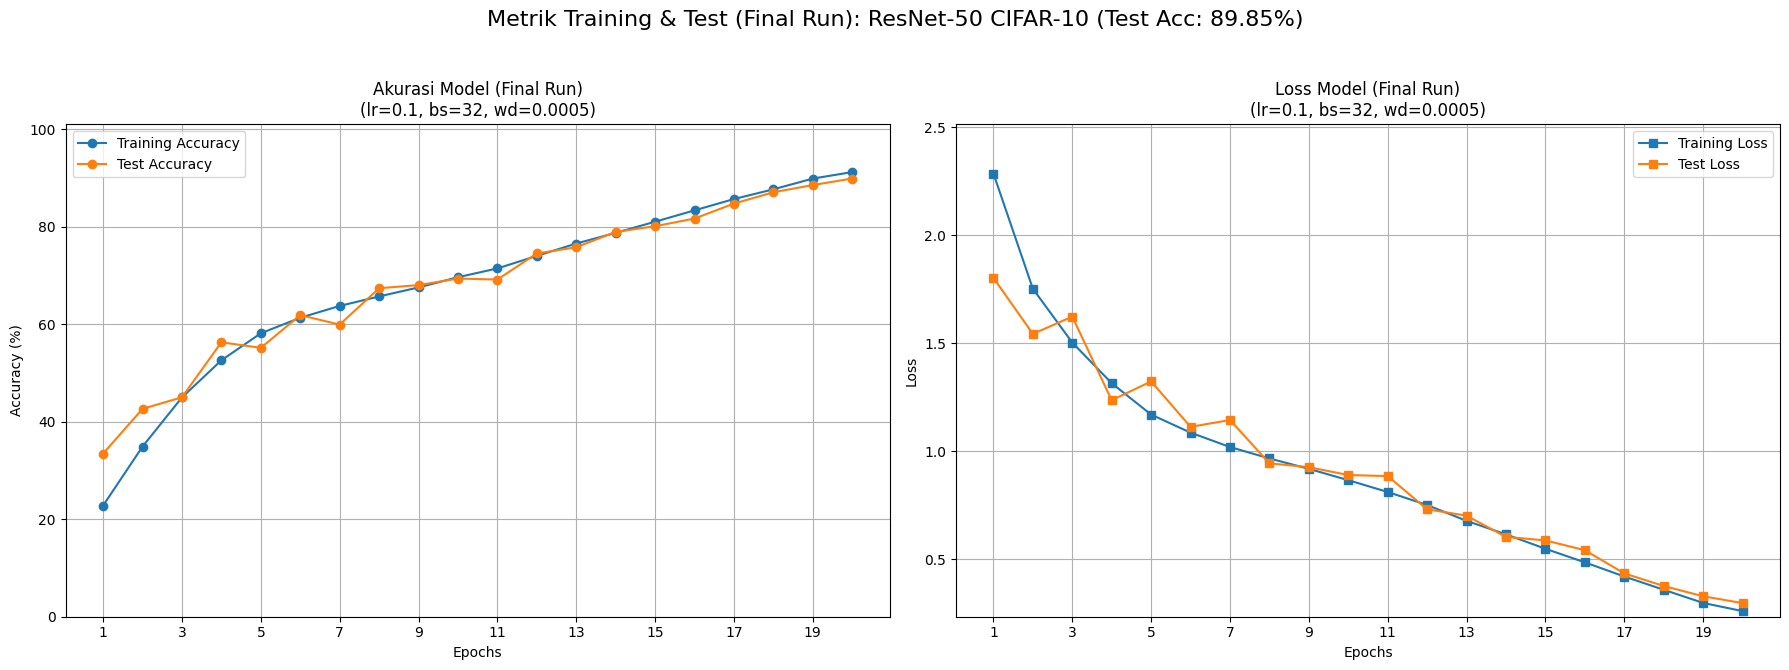

In [ ]:
if final_train_acc_hist: # Hanya proses jika ada history
    actual_epochs_final_run = len(final_train_acc_hist)
    epochs_range_final = range(1, actual_epochs_final_run + 1)

    # --- Membuat Tabel ---
    print("\n--- Tabel Metrik per Epoch ---")
    # Header tabel
    print(f"{'Epoch':<7} | {'Train Acc (%)':<15} | {'Test Acc (%)':<14} | {'Train Loss':<12} | {'Test Loss':<10}")
    print("-" * 70)
    for i in range(actual_epochs_final_run):
        epoch_num = i + 1
        train_acc = final_train_acc_hist[i]
        test_acc = final_test_acc_hist[i] # Menggunakan final_test_acc_hist
        train_loss = final_train_loss_hist[i]
        test_loss = final_test_loss_hist[i] # Menggunakan final_test_loss_hist
        print(f"{epoch_num:<7} | {train_acc:<15.2f} | {test_acc:<14.2f} | {train_loss:<12.4f} | {test_loss:<10.4f}")
    print("-" * 70)

    # --- Membuat Grafik ---
    plt.figure(figsize=(18, 7)) # Sedikit lebih lebar untuk judul yang lebih panjang

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range_final, final_train_acc_hist, label='Training Accuracy', marker='o', linestyle='-')
    plt.plot(epochs_range_final, final_test_acc_hist, label='Test Accuracy', marker='o', linestyle='-') # Menggunakan final_test_acc_hist
    plt.title(f'Akurasi Model (Final Run)\n(lr={best_lr}, bs={best_batch_size}, wd={best_weight_decay})')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
    tick_interval = max(1, actual_epochs_final_run // 10 if actual_epochs_final_run > 10 else 1)
    plt.xticks(range(1, actual_epochs_final_run + 1, tick_interval))
    plt.legend(); plt.grid(True); plt.ylim(0, 101)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range_final, final_train_loss_hist, label='Training Loss', marker='s', linestyle='-')
    plt.plot(epochs_range_final, final_test_loss_hist, label='Test Loss', marker='s', linestyle='-') # Menggunakan final_test_loss_hist
    plt.title(f'Loss Model (Final Run)\n(lr={best_lr}, bs={best_batch_size}, wd={best_weight_decay})')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.xticks(range(1, actual_epochs_final_run + 1, tick_interval))
    plt.legend(); plt.grid(True)
    min_l, max_l = (min(final_train_loss_hist + final_test_loss_hist) if final_train_loss_hist and final_test_loss_hist else 0), \
                   (max(final_train_loss_hist + final_test_loss_hist) if final_train_loss_hist and final_test_loss_hist else 1)
    if min_l == max_l : max_l += 0.1
    plt.ylim(bottom=max(0, min_l - 0.1*abs(min_l if min_l !=0 else 0.01)), top=max_l + 0.1*abs(max_l if max_l != 0 else 0.01) if max_l > 0 else 0.1)

    plt.suptitle(f'Metrik Training & Test (Final Run): ResNet-50 CIFAR-10 (Test Acc: {final_test_acc_run:.2f}%)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()
else:
    print("Tidak ada riwayat training yang valid untuk diplot atau dibuat tabelnya untuk final run.")


In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch.nn.functional as F

def visualize_feature_maps(model, img, true_label, pred_label, class_names, device, num_filters=8):
    model.eval()
    img = img.to(device).unsqueeze(0)

    # Daftar layer konvolusi (ganti sesuai struktur model kamu)
    conv_layers = [model.conv1, model.conv2, model.conv3]
    norm_layers = [model.bn1, model.bn2, model.bn3]

    x = img
    feature_maps_all = []

    # Ambil feature map dari setiap conv layer
    for i, conv in enumerate(conv_layers):
        x = conv(x)
        x = norm_layers[i](x)
        x = F.relu(x)
        fmap = x[0].detach().cpu().numpy()
        feature_maps_all.append(fmap)

    # Convert input image untuk overlay (dari tensor ke numpy)
    img_np = img[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np / 2 + 0.5) * 255
    img_np = img_np.astype(np.uint8)

    # Plot
    fig, axes = plt.subplots(len(feature_maps_all) + 1, num_filters, figsize=(num_filters * 2, 10))
    fig.suptitle(f"Ground Truth: {class_names[true_label]} | Predicted: {class_names[pred_label]}", fontsize=16)

    # Tampilkan gambar asli
    for i in range(num_filters):
        if i == 0:
            axes[0, i].imshow(img_np)
            axes[0, i].set_title("Input Image")
        else:
            axes[0, i].axis("off")

    # Tampilkan feature maps
    for layer_idx, fmap in enumerate(feature_maps_all):
        for i in range(num_filters):
            fmap_i = fmap[i]
            fmap_norm = cv2.normalize(fmap_i, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            heatmap = cv2.applyColorMap(fmap_norm, cv2.COLORMAP_JET)
            overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
            overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
            axes[layer_idx + 1, i].imshow(overlay)
            axes[layer_idx + 1, i].set_title(f"Layer {layer_idx+1} | F{i}")
            axes[layer_idx + 1, i].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig("feature_map_overlay_visual.png")
    plt.show()


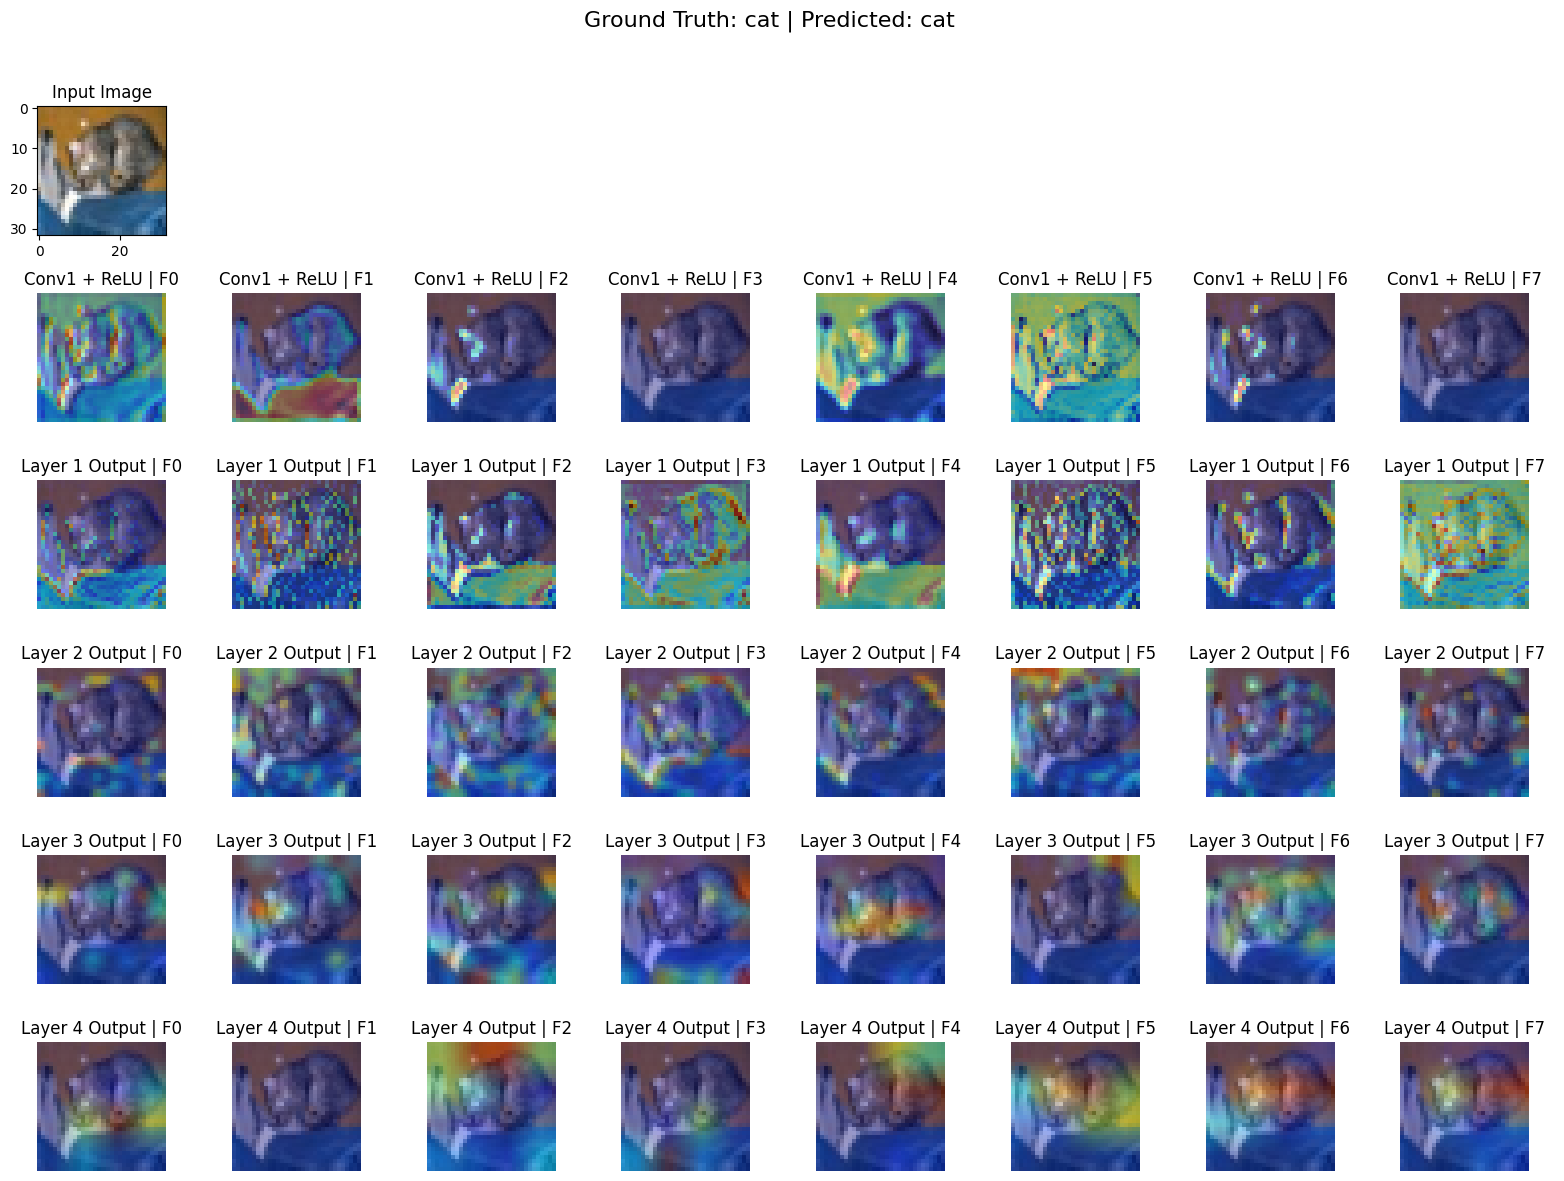

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader # Make sure DataLoader is imported

def visualize_feature_maps(model, img, true_label, pred_label, class_names, device, num_filters=8):
    model.eval()
    img = img.to(device).unsqueeze(0)

    feature_maps_all = []
    layer_names = []

    # Initial conv + ReLU
    x = model.conv1(img)
    x = model.bn1(x)
    x = model.relu(x)
    feature_maps_all.append(x[0].detach().cpu().numpy())
    layer_names.append("Conv1 + ReLU")

    # Layer 1
    x = model.layer1(x)
    feature_maps_all.append(x[0].detach().cpu().numpy())
    layer_names.append("Layer 1 Output")

    # Layer 2
    x = model.layer2(x)
    feature_maps_all.append(x[0].detach().cpu().numpy())
    layer_names.append("Layer 2 Output")

    # Layer 3
    x = model.layer3(x)
    feature_maps_all.append(x[0].detach().cpu().numpy())
    layer_names.append("Layer 3 Output")

    # Layer 4
    x = model.layer4(x)
    feature_maps_all.append(x[0].detach().cpu().numpy())
    layer_names.append("Layer 4 Output")

    try:
        CIFAR_MEAN_T = torch.tensor(CIFAR_MEAN, device=img[0].device).view(3, 1, 1)
        CIFAR_STD_T = torch.tensor(CIFAR_STD, device=img[0].device).view(3, 1, 1)
        # De-normalize the image tensor
        img_denorm = img[0] * CIFAR_STD_T + CIFAR_MEAN_T
        img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
        # Convert to uint8 (0-255) - clamp values as they might be outside [0, 1] after denorm
        img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
        # Convert from RGB to BGR for OpenCV functions
        img_np_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        overlay_possible = True
    except NameError:
        print("CIFAR_MEAN or CIFAR_STD not found. Skipping feature map overlay visualization.")
        img_np_bgr = None
        overlay_possible = False


    # Plot
    num_layers_to_plot = len(feature_maps_all)
    fig, axes = plt.subplots(num_layers_to_plot + 1, num_filters, figsize=(num_filters * 2, (num_layers_to_plot + 1) * 2))
    fig.suptitle(f"Ground Truth: {class_names[true_label]} | Predicted: {class_names[pred_label]}", fontsize=16)

    # Tampilkan gambar asli
    for i in range(num_filters):
        if i == 0:
            if overlay_possible:
                 # Display the original image (denormalized)
                 axes[0, i].imshow(img_np)
                 axes[0, i].set_title("Input Image")
            else:
                 axes[0, i].text(0.5, 0.5, "Overlay Skipped (Normalization details missing)", horizontalalignment='center', verticalalignment='center')
                 axes[0, i].axis("off")
        else:
            axes[0, i].axis("off")

    # Tampilkan feature maps
    for layer_idx, fmap in enumerate(feature_maps_all):
        layer_name = layer_names[layer_idx]
        # Ensure we don't try to plot more filters than exist in the feature map
        num_filters_this_layer = min(num_filters, fmap.shape[0])

        for i in range(num_filters_this_layer):
            fmap_i = fmap[i]
            # Normalize feature map to 0-255
            fmap_norm = cv2.normalize(fmap_i, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

            if overlay_possible:
                heatmap = cv2.applyColorMap(fmap_norm, cv2.COLORMAP_JET)
                # Resize heatmap to match original image size for overlay
                heatmap_resized = cv2.resize(heatmap, (img_np_bgr.shape[1], img_np_bgr.shape[0]))
                overlay = cv2.addWeighted(img_np_bgr, 0.6, heatmap_resized, 0.4, 0)
                overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
                axes[layer_idx + 1, i].imshow(overlay)
            else:
                # If overlay is not possible, just show the heatmap
                 heatmap = cv2.applyColorMap(fmap_norm, cv2.COLORMAP_JET)
                 heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
                 axes[layer_idx + 1, i].imshow(heatmap_rgb)


            axes[layer_idx + 1, i].set_title(f"{layer_name} | F{i}")
            axes[layer_idx + 1, i].axis("off")

        # Turn off remaining axes in this row if num_filters is more than actual filters
        for i in range(num_filters_this_layer, num_filters):
             axes[layer_idx + 1, i].axis("off")


    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    # Consider dynamic filename or just display
    # plt.savefig("feature_map_overlay_visual.png")
    plt.show()

# Then, the calling code remains the same:
# Get a batch from the test loader
class_names = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
# dataiter = iter(test_loader) # Original line
dataiter = iter(final_test_loader) # Use the correctly named test loader from final training
images, labels = next(dataiter)

# Select the first image from the batch
img = images[0]
true_label = labels[0].item()

model_to_visualize = final_model # Use the model trained with best hyperparameters
model_to_visualize.eval() # Set the model to evaluation mode

with torch.no_grad():
    img_for_pred = img.unsqueeze(0).to(device) # Add batch dimension and move to device
    outputs = model_to_visualize(img_for_pred)
    _, predicted = torch.max(outputs.data, 1)
    pred_label = predicted.item()

# Now call the visualize_feature_maps function with the obtained variables
visualize_feature_maps(model_to_visualize, img, true_label, pred_label, class_names, device)

In [ ]:
# Fungsi untuk mengumpulkan prediksi dan label dari dataloader
def predictions_and_labels(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            test_preds = model(inputs)
            _, preds = test_preds.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

<Figure size 1000x800 with 0 Axes>

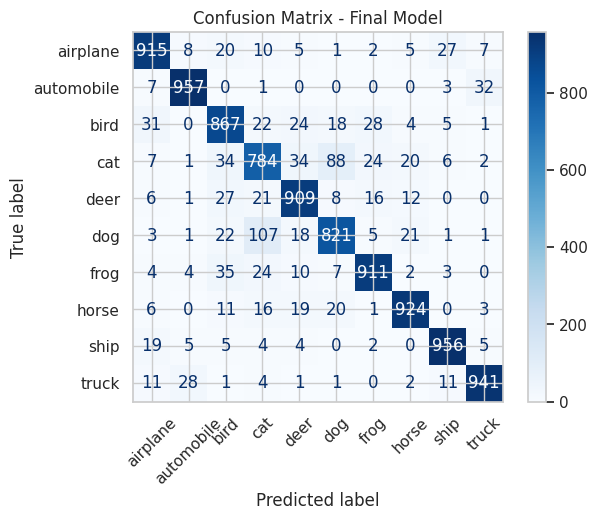

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Pastikan model dalam mode evaluasi
final_model.eval()

# Simpan semua label dan prediksi
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Hitung confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.classes  # Jika dataset kamu adalah CIFAR-10 asli

# Tampilkan confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Final Model")
plt.show()


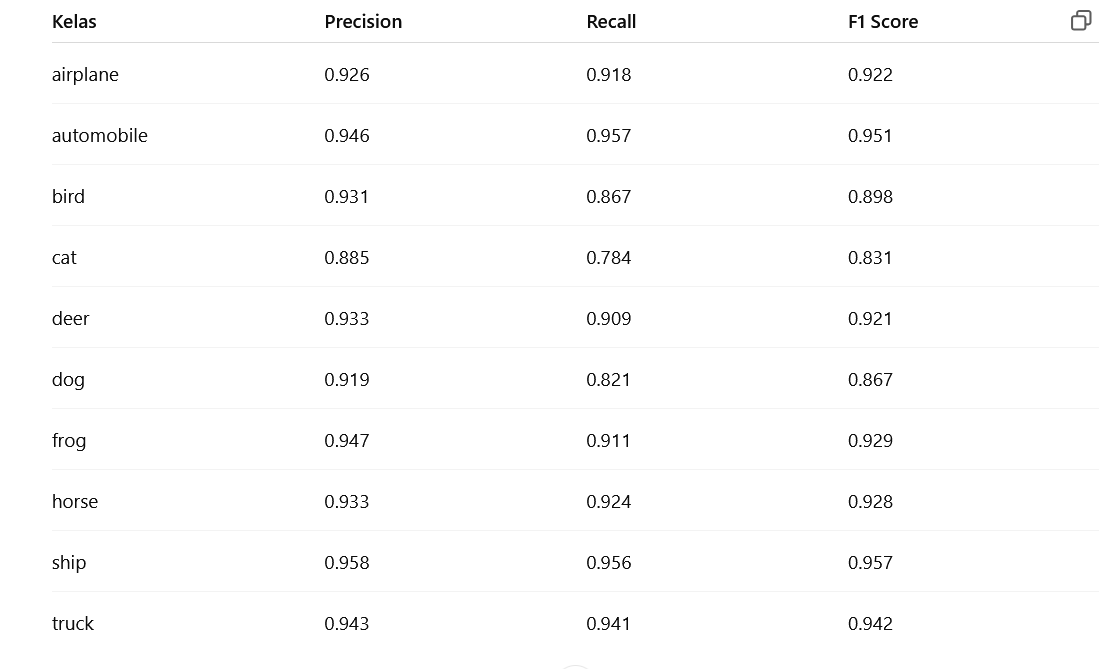